# Sports Person Classifier — model development

The app identifies five athletes in a photo. This notebook walks through the final pipeline
(the same code lives in `model/train.py` and `server/face_engine.py`):

1. **Detect** faces with YuNet
2. **Embed** each aligned face into a 128-d vector with SFace
3. **Classify** the embedding with an SVM / logistic regression
4. **Reject strangers** using similarity to the known faces

Earlier versions used Haar cascades + raw pixels + wavelets (~81% on a small split). Face embeddings do much better.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "server").exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "server")); sys.path.insert(0, str(ROOT / "model"))

import numpy as np, cv2, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import train
from face_engine import FaceEngine

## 1. Detection demo

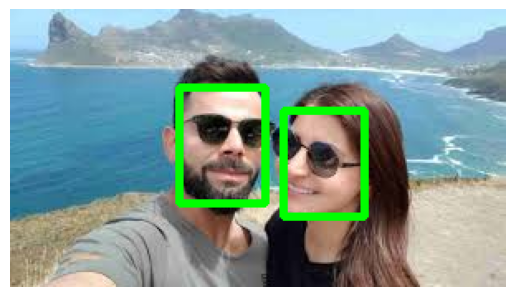

In [2]:
engine = FaceEngine()
img = cv2.imread(str(ROOT / "UI" / "test_images" / "kohli_2.jpg"))
img, _ = engine.shrink(img)
for f in engine.detect(img):
    x, y, w, h = map(int, f[:4]); cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off");

## 2. Build the embedding dataset
Each photo contributes the embedding of its largest face plus its horizontal flip. `groups` keeps a photo and its flip together, so cross-validation never leaks.

In [3]:
X, y, groups, class_dict = train.load_dataset(engine)
names = sorted(class_dict, key=class_dict.get)
print(X.shape, np.bincount(y))

lionel_messi       used  52  skipped 1


maria_sharapova    used  72  skipped 4


roger_federer      used  58  skipped 0


serena_williams    used  61  skipped 0


virat_kohli        used 104  skipped 0
(694, 128) [104 144 116 122 208]


## 3. Model selection (grouped, stratified 5-fold CV)

In [4]:
cv = list(StratifiedGroupKFold(5, shuffle=True, random_state=0).split(X, y, groups))
models = {
    "logreg C=100": LogisticRegression(C=100, max_iter=5000),
    "svm rbf C=10": SVC(C=10, probability=True, random_state=0),
}
oof = {}
for name, m in models.items():
    p = np.zeros((len(y), len(names)))
    for tr, te in cv:
        p[te] = m.fit(X[tr], y[tr]).predict_proba(X[te])
    oof[name] = p
    print(f"{name:14s} accuracy {(p.argmax(1) == y).mean():.3f}")

logreg C=100   accuracy 0.942


svm rbf C=10   accuracy 0.948


                 precision    recall  f1-score   support

   lionel_messi       1.00      0.95      0.98       104
maria_sharapova       0.87      0.94      0.91       144
  roger_federer       0.98      0.95      0.96       116
serena_williams       0.92      0.90      0.91       122
    virat_kohli       0.98      0.98      0.98       208

       accuracy                           0.95       694
      macro avg       0.95      0.94      0.95       694
   weighted avg       0.95      0.95      0.95       694



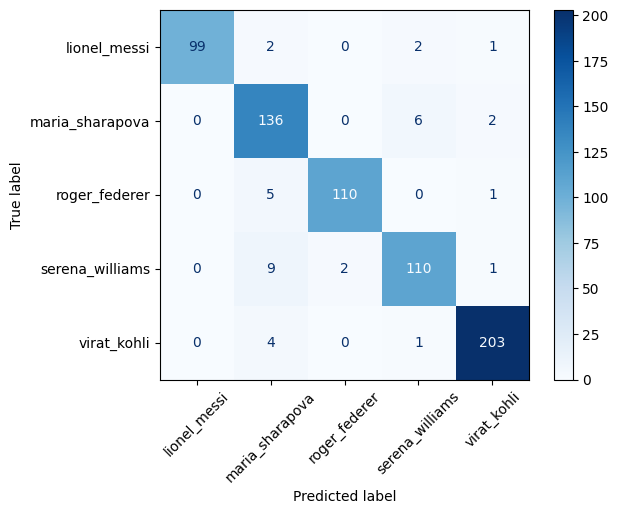

In [5]:
best = oof["svm rbf C=10"]
print(classification_report(y, best.argmax(1), target_names=names))
ConfusionMatrixDisplay.from_predictions(y, best.argmax(1), display_labels=names, xticks_rotation=45, cmap="Blues");

## 4. Rejecting people the model doesn't know
A closed-set classifier must answer with one of the five athletes, even for a stranger. We measure how similar a face is to the 3 closest known faces of the predicted athlete; real matches score high, strangers low.

accepts 89% of genuine, 4% of impostors


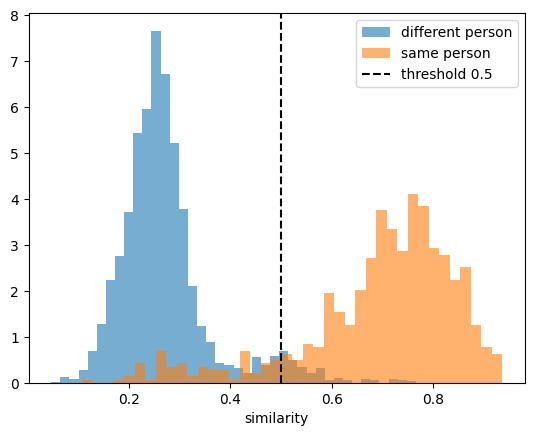

In [6]:
def sim(q, gx, gy, c, k=3): return np.sort(gx[gy == c] @ q)[::-1][:k].mean()
genuine, impostor = [], []
for tr, te in cv:
    for i in te:
        genuine.append(sim(X[i], X[tr], y[tr], y[i]))
        impostor += [sim(X[i], X[tr], y[tr], c) for c in set(y) - {y[i]}]
plt.hist(impostor, 40, alpha=.6, density=True, label="different person")
plt.hist(genuine, 40, alpha=.6, density=True, label="same person")
plt.axvline(0.5, color="k", ls="--", label="threshold 0.5"); plt.xlabel("similarity"); plt.legend();
print("accepts", f"{(np.array(genuine) >= .5).mean():.0%} of genuine,", f"{(np.array(impostor) >= .5).mean():.0%} of impostors")

## 5. Train and export
Run `python model/train.py` to refit on all data and write `server/artifacts/` (model, class map, gallery embeddings).